In [6]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
SEED = 69
import tensorflow as tf
import keras
keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
print('Seed set')

Seed set


In [7]:
!pip install kagglehub -q

In [8]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import applications, callbacks, layers, models, optimizers, regularizers, utils
warnings.filterwarnings('ignore')
print('Libraries ready')

Libraries ready


In [9]:
import kagglehub
download_path = kagglehub.dataset_download('msambare/fer2013')

def find_split_root(base_path):
    base = Path(base_path)
    for root, dirs, files in os.walk(base):
        if 'train' in dirs and 'test' in dirs:
            return Path(root)
    return base

dataset_dir = find_split_root(download_path)
train_dir   = str(dataset_dir / 'train')
test_dir    = str(dataset_dir / 'test')
print('Train:', train_dir)
print('Test: ', test_dir)

Train: /kaggle/input/datasets/msambare/fer2013/train
Test:  /kaggle/input/datasets/msambare/fer2013/test


In [10]:
emotion_classes = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d)) and not d.startswith('.')
])
NUM_CLASSES = len(emotion_classes)

class_counts_train, class_counts_test = {}, {}
for cls in emotion_classes:
    class_counts_train[cls] = len(os.listdir(os.path.join(train_dir, cls)))
    class_counts_test[cls]  = len(os.listdir(os.path.join(test_dir,  cls)))
    print(f'  {cls:12s} -> train: {class_counts_train[cls]:5d} | test: {class_counts_test[cls]:5d}')
print(f'Total train: {sum(class_counts_train.values())} | Total test: {sum(class_counts_test.values())}')

  angry        -> train:  3995 | test:   958
  disgust      -> train:   436 | test:   111
  fear         -> train:  4097 | test:  1024
  happy        -> train:  7215 | test:  1774
  neutral      -> train:  4965 | test:  1233
  sad          -> train:  4830 | test:  1247
  surprise     -> train:  3171 | test:   831
Total train: 28709 | Total test: 7178


In [11]:
corrupted = []
for split_dir in [train_dir, test_dir]:
    for cls in emotion_classes:
        cls_path = os.path.join(split_dir, cls)
        for f in os.listdir(cls_path):
            if f.lower().endswith(('.jpg','.jpeg','.png')):
                p = os.path.join(cls_path, f)
                try: Image.open(p).verify()
                except: corrupted.append(p)
for p in corrupted:
    try: os.remove(p)
    except: pass
print(f'Removed {len(corrupted)} corrupted' if corrupted else 'No corrupted images')

No corrupted images


In [12]:
IMG_SIZE   = 112   # نص 224 — سرعة ضعف مع accuracy قريبة
BATCH_SIZE = 128   # أسرع بكتير
AUTOTUNE   = tf.data.AUTOTUNE

labels_flat = []
for idx, cls in enumerate(emotion_classes):
    labels_flat.extend([idx] * class_counts_train[cls])
cw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=np.array(labels_flat))
class_weight_dict = {i: w for i, w in enumerate(cw)}
print(f'IMG_SIZE: {IMG_SIZE} | BATCH_SIZE: {BATCH_SIZE}')

IMG_SIZE: 112 | BATCH_SIZE: 128


In [13]:
def augment_single(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.15)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    pad   = 8
    image = tf.image.pad_to_bounding_box(image, pad, pad, IMG_SIZE+2*pad, IMG_SIZE+2*pad)
    image = tf.image.random_crop(image, [IMG_SIZE, IMG_SIZE, 3])
    return image

def make_dataset(directory, training=False):
    ds = utils.image_dataset_from_directory(
        directory,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        color_mode='rgb',
        shuffle=training,
        seed=SEED
    )
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (tf.map_fn(augment_single, x, dtype=tf.float32), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = make_dataset(train_dir, training=True)
test_ds  = make_dataset(test_dir,  training=False)
print(f'Train batches: {len(train_ds)} | Test batches: {len(test_ds)}')

Found 28709 files belonging to 7 classes.


I0000 00:00:1787454882.489443      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787454882.492451      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Instructions for updating:
Use fn_output_signature instead
Found 7178 files belonging to 7 classes.
Train batches: 225 | Test batches: 57


In [14]:
base = applications.EfficientNetV2S(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet',
    include_preprocessing=True
)
base.trainable = True

inputs  = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base(inputs, training=True)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.BatchNormalization()(x)
x       = layers.Activation('relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('Model ready')

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model ready


In [15]:
cb = [
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        'best_effv2s.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=25,
    callbacks=cb,
    class_weight=class_weight_dict,
    verbose=1
)
print(f'Done — Best Val Acc: {max(history.history["val_accuracy"]):.4f}')

Epoch 1/25


E0000 00:00:1787454963.445279      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetv2-s_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


225/225 ━━━━━━━━━━━━━━━━━━━━ 266s 797ms/step - accuracy: 0.2588 - loss: 2.0963 - val_accuracy: 0.3911 - val_loss: 1.6138 - learning_rate: 1.0000e-04
Epoch 2/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 175s 778ms/step - accuracy: 0.3682 - loss: 1.6733 - val_accuracy: 0.4553 - val_loss: 1.4457 - learning_rate: 1.0000e-04
Epoch 3/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 175s 778ms/step - accuracy: 0.4469 - loss: 1.4524 - val_accuracy: 0.5014 - val_loss: 1.3346 - learning_rate: 1.0000e-04
Epoch 4/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 175s 779ms/step - accuracy: 0.4992 - loss: 1.3200 - val_accuracy: 0.5401 - val_loss: 1.2555 - learning_rate: 1.0000e-04
Epoch 5/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 175s 778ms/step - accuracy: 0.5396 - loss: 1.2081 - val_accuracy: 0.5720 - val_loss: 1.1855 - learning_rate: 1.0000e-04
Epoch 6/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 175s 779ms/step - accuracy: 0.5683 - loss: 1.1289 - val_accuracy: 0.5822 - val_loss: 1.1522 - learning_rate: 1.0000e-04
Epoch 7/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 175s 778ms/

In [20]:
!pip install tf2onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 18.9 MB/s eta 0:00:0000:01


In [21]:
import tf2onnx

tf2onnx.convert.from_keras(
    model,
    opset=18,
    output_path="best_effv2s.onnx"
)

print("Saved: best_effv2s.onnx")

I0000 00:00:1787459435.540980      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1787459435.541252      58 single_machine.cc:376] Starting new session
I0000 00:00:1787459435.556693      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787459435.558401      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1787459442.254058      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787459442.255744      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 M

Saved: best_effv2s.onnx


In [22]:
print(os.path.abspath("best_effv2s.onnx"))

/kaggle/working/best_effv2s.onnx


In [ ]:
import onnx

onnx_model = onnx.load("best_effv2s.onnx")
onnx.checker.check_model(onnx_model)

print("ONNX model is valid.")

In [16]:
model.save('efficientnetv2s_fer2013.h5')
from google.colab import files
files.download('efficientnetv2s_fer2013.h5')
print('Saved!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved!


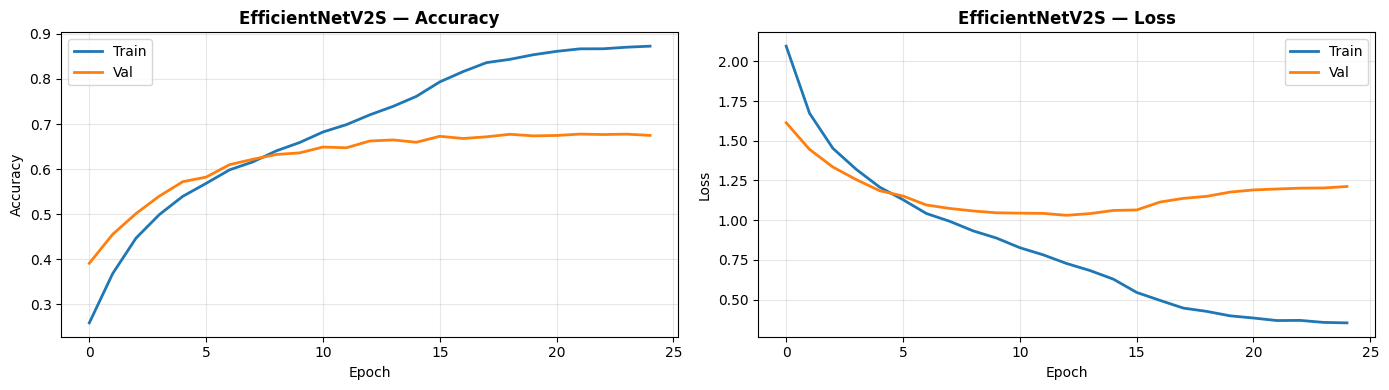

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, ylabel in zip(axes, ['accuracy','loss'], ['Accuracy','Loss']):
    ax.plot(history.history[metric],          label='Train', linewidth=2)
    ax.plot(history.history[f'val_{metric}'], label='Val',   linewidth=2)
    ax.set_title(f'EfficientNetV2S — {ylabel}', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
class_names = sorted(os.listdir(train_dir))
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

all_preds, all_labels = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(np.argmax(labels.numpy(), axis=1))

print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

Test Loss:     1.1964
Test Accuracy: 0.6776
              precision    recall  f1-score   support

       angry     0.6155    0.5898    0.6023       958
     disgust     0.7383    0.7117    0.7248       111
        fear     0.5695    0.5039    0.5347      1024
       happy     0.8867    0.8382    0.8618      1774
     neutral     0.6009    0.6667    0.6321      1233
         sad     0.5378    0.5814    0.5588      1247
    surprise     0.7845    0.8063    0.7953       831

    accuracy                         0.6776      7178
   macro avg     0.6762    0.6711    0.6728      7178
weighted avg     0.6814    0.6776    0.6786      7178



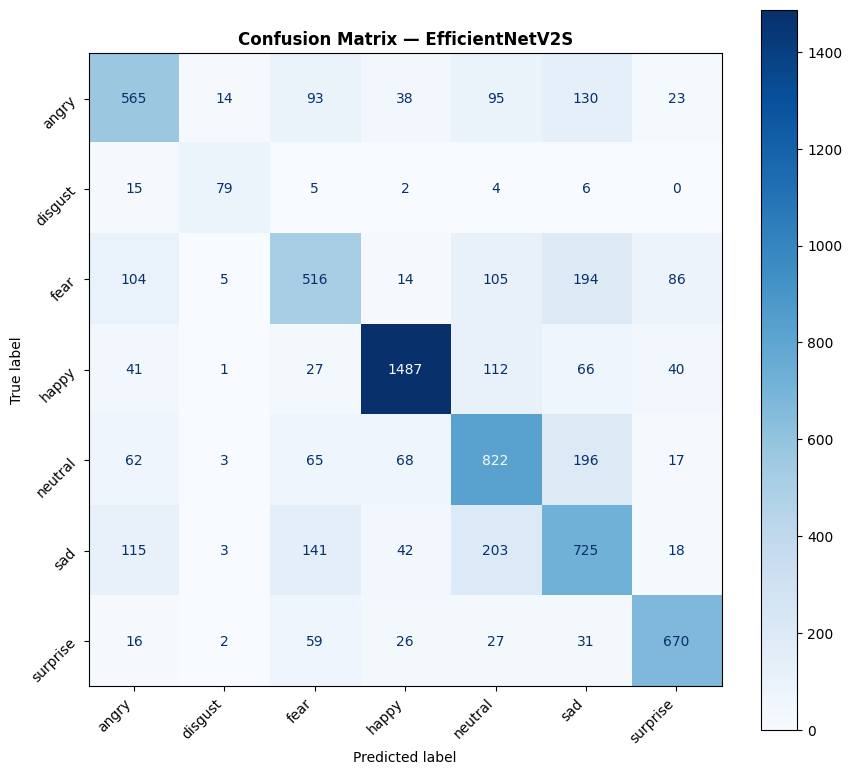

In [19]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix — EfficientNetV2S', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()